# 04 — Feature Engineering

## Objective
Transform cleaned booking-time features into a model-ready
feature matrix for 3-class ride cancellation prediction.

## What This Notebook Covers
1. Enforce data leakage rule — remove post-outcome columns
2. Investigate and handle driver_cancellations_today (NaN issue)
3. Cyclical encoding of hour and month
4. Ordinal encoding of weather_condition
5. Target encoding of pickup_zone and drop_zone
   (using cancellation rate, not surge rate)
6. One-hot encoding of day_of_week and vehicle_type
7. New domain-specific engineered features
8. Handle class imbalance — class weights + SMOTE
9. Final feature matrix assembly
10. Save modeling dataset

## Key Differences from Surge Pricing Feature Engineering
- Target is 3-class (0/1/2), not continuous
- Data leakage rule must be explicitly enforced
- Class imbalance requires special handling
- Target encoding uses cancellation rate, not surge

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.utils.class_weight import compute_class_weight
import warnings
warnings.filterwarnings("ignore")

# SMOTE — install if needed: pip install imbalanced-learn
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print("SMOTE available ✅")
except ImportError:
    SMOTE_AVAILABLE = False
    print("SMOTE not installed — run: pip install imbalanced-learn")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

OUTCOME_COLORS = {0: "#4CAF50", 1: "#F44336", 2: "#FF9800"}
OUTCOME_LABELS = {0: "Completed", 1: "Driver Cancel", 2: "User Cancel"}

print("Libraries loaded ✅")

SMOTE not installed — run: pip install imbalanced-learn
Libraries loaded ✅


In [2]:
PATH = "../data/processed/"

rides_df = pd.read_csv(PATH + "rides_clean.csv", parse_dates=["ride_timestamp"])

print(f"Rides loaded : {rides_df.shape}")
print(f"\nAll columns ({len(rides_df.columns)}):")
for col in rides_df.columns:
    print(f"  {col:<35} {rides_df[col].dtype}")

Rides loaded : (60000, 34)

All columns (34):
  ride_id                             str
  driver_id                           str
  user_id                             str
  pickup_zone                         str
  drop_zone                           str
  pickup_lat                          float64
  pickup_lon                          float64
  drop_lat                            float64
  drop_lon                            float64
  pickup_accuracy_score               float64
  ride_timestamp                      datetime64[us]
  hour                                int64
  month                               int64
  day_of_week                         str
  is_weekend                          bool
  is_holiday                          bool
  vehicle_type                        str
  weather_condition                   str
  driver_distance_to_pickup_km        float64
  driver_rating_at_booking            float64
  driver_acceptance_rate              float64
  driver_cancellations_

## Step 1 — Enforce Data Leakage Rule

The following columns MUST be removed before building the
feature matrix. They are only available AFTER the ride
outcome is determined — using them would let the model
"cheat" by seeing the answer at prediction time.

### Columns to Remove (Post-Outcome)
| Column | Why It Leaks |
|---|---|
| distance_km | Only exists for completed rides |
| duration_min | Only exists for completed rides |
| fare_amount | Only exists for completed rides |
| time_to_cancellation_min | Only exists for cancelled rides |
| cancelled_by | Literally describes the outcome |
| cancellation_reason | Literally describes the outcome |
| outcome_label | Text version of target variable |

### Columns to Keep as Reference (Not Features)
| Column | Why We Keep It |
|---|---|
| ride_id | For tracing predictions back to rides |
| ride_timestamp | For time-based analysis, not modeling |
| ride_outcome | This IS the target variable |

In [3]:
# Columns that leak the answer — must never be features
leaky_cols = [
    "distance_km", "duration_min", "fare_amount",
    "time_to_cancellation_min", "cancelled_by",
    "cancellation_reason", "outcome_label",
]

# Reference columns — keep but not features
reference_cols = ["ride_id", "ride_timestamp"]

# Target variable
TARGET = "ride_outcome"

# Drop leaky columns — only those that actually exist
leaky_cols_present = [c for c in leaky_cols if c in rides_df.columns]
rides_df = rides_df.drop(columns=leaky_cols_present)

print(f"Leaky columns removed: {leaky_cols_present}")
print(f"\nRemaining shape: {rides_df.shape}")
print(f"\nRemaining columns:")
for col in rides_df.columns:
    print(f"  {col}")

Leaky columns removed: ['distance_km', 'duration_min', 'fare_amount', 'time_to_cancellation_min', 'cancelled_by', 'cancellation_reason']

Remaining shape: (60000, 28)

Remaining columns:
  ride_id
  driver_id
  user_id
  pickup_zone
  drop_zone
  pickup_lat
  pickup_lon
  drop_lat
  drop_lon
  pickup_accuracy_score
  ride_timestamp
  hour
  month
  day_of_week
  is_weekend
  is_holiday
  vehicle_type
  weather_condition
  driver_distance_to_pickup_km
  driver_rating_at_booking
  driver_acceptance_rate
  driver_cancellations_today
  user_rating_at_booking
  user_cancellations_last_30d
  user_booking_attempts
  estimated_wait_time_min
  surge_at_booking
  ride_outcome


## Step 2 — Investigate driver_cancellations_today

EDA found this column showed all zeros across all outcome classes
and returned NaN in the correlation calculation.

We need to understand WHY before deciding what to do.

Possible reasons:
1. The daily counter reset properly in the generator but the
   lookup dict returned 0 for all new rides correctly
2. A bug caused the counter to never increment
3. The column genuinely has no variance — all zeros

We diagnose by checking the value distribution.

In [4]:
print("driver_cancellations_today value distribution:")
print(rides_df["driver_cancellations_today"].value_counts().sort_index())

print(f"\nUnique values: {rides_df['driver_cancellations_today'].nunique()}")
print(f"Min: {rides_df['driver_cancellations_today'].min()}")
print(f"Max: {rides_df['driver_cancellations_today'].max()}")
print(f"Mean: {rides_df['driver_cancellations_today'].mean():.4f}")
print(f"Null count: {rides_df['driver_cancellations_today'].isnull().sum()}")

driver_cancellations_today value distribution:
driver_cancellations_today
0    60000
Name: count, dtype: int64

Unique values: 1
Min: 0
Max: 0
Mean: 0.0000
Null count: 0


### Decision on driver_cancellations_today

If the column shows all zeros or near-zero variance:
→ DROP it — a column with no variance carries zero
  information for the model. Including it wastes a
  feature slot and can slightly confuse some models.

If it shows some variance:
→ KEEP it and cap outliers before using.

We document the decision based on the output above.

In [5]:
variance = rides_df["driver_cancellations_today"].var()
unique_count = rides_df["driver_cancellations_today"].nunique()

print(f"Variance: {variance:.6f}")
print(f"Unique values: {unique_count}")

if unique_count <= 2 or variance < 0.01:
    rides_df = rides_df.drop(columns=["driver_cancellations_today"])
    print("\n⚠️ Dropped driver_cancellations_today — near-zero variance")
    print("   Reason: column carries no predictive signal")
    DROPPED_DRIVER_CANCEL_TODAY = True
else:
    print("\n✅ Keeping driver_cancellations_today — has meaningful variance")
    DROPPED_DRIVER_CANCEL_TODAY = False

Variance: 0.000000
Unique values: 1

⚠️ Dropped driver_cancellations_today — near-zero variance
   Reason: column carries no predictive signal


## Step 3 — Cyclical Encoding of Hour and Month

Same approach as surge pricing — hour and month are
circular, not linear. Hour 23 and hour 0 are adjacent.
December and January are adjacent.

sin and cos together uniquely place each value on a circle.

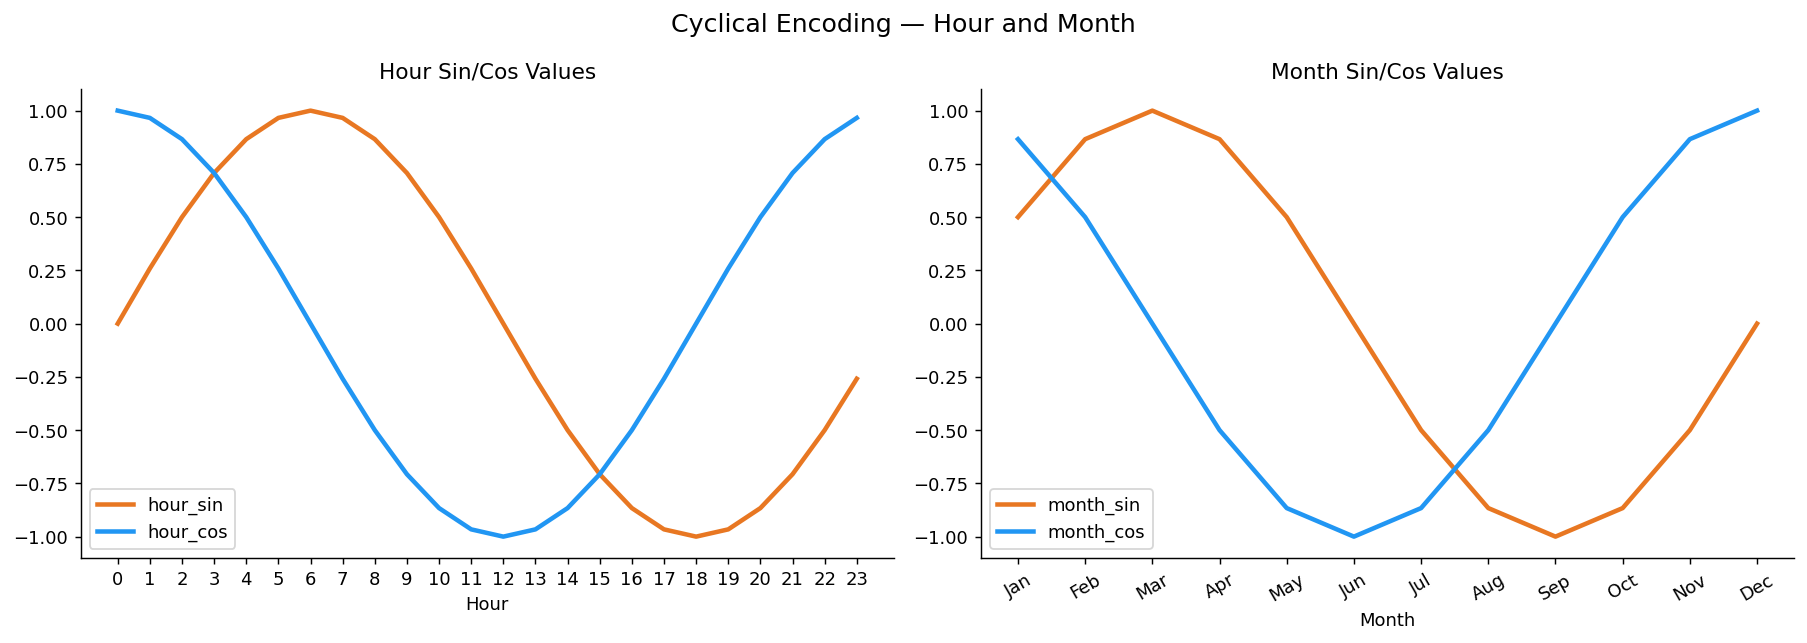

✅ Cyclical encoding applied to hour and month


In [6]:
# Hour
rides_df["hour_sin"] = np.sin(2 * np.pi * rides_df["hour"] / 24)
rides_df["hour_cos"] = np.cos(2 * np.pi * rides_df["hour"] / 24)

# Month
rides_df["month_sin"] = np.sin(2 * np.pi * rides_df["month"] / 12)
rides_df["month_cos"] = np.cos(2 * np.pi * rides_df["month"] / 12)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Cyclical Encoding — Hour and Month", fontsize=14)

hours = np.arange(0, 24)
axes[0].plot(hours, np.sin(2*np.pi*hours/24),
             color="#E87722", linewidth=2.5, label="hour_sin")
axes[0].plot(hours, np.cos(2*np.pi*hours/24),
             color="#2196F3", linewidth=2.5, label="hour_cos")
axes[0].set_title("Hour Sin/Cos Values")
axes[0].set_xlabel("Hour")
axes[0].set_xticks(hours)
axes[0].legend()

months = np.arange(1, 13)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
axes[1].plot(months, np.sin(2*np.pi*months/12),
             color="#E87722", linewidth=2.5, label="month_sin")
axes[1].plot(months, np.cos(2*np.pi*months/12),
             color="#2196F3", linewidth=2.5, label="month_cos")
axes[1].set_title("Month Sin/Cos Values")
axes[1].set_xlabel("Month")
axes[1].set_xticks(months)
axes[1].set_xticklabels(month_labels, rotation=30)
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/fe_01_cyclical_encoding.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("✅ Cyclical encoding applied to hour and month")

## Step 4 — Ordinal Encoding of Weather Condition

Identical to surge pricing — weather has a natural severity
order from Clear to Storm. Ordinal encoding preserves this
order. One-hot encoding would treat all conditions as equally
different from each other — incorrect for weather severity.

In [7]:
weather_ordinal_map = {
    "Clear"      : 0,
    "Cloudy"     : 1,
    "Foggy"      : 2,
    "Light Rain" : 3,
    "Heavy Rain" : 4,
    "Storm"      : 5,
}

rides_df["weather_encoded"] = rides_df["weather_condition"].map(weather_ordinal_map)

nulls = rides_df["weather_encoded"].isnull().sum()
print(f"Weather ordinal encoding complete")
print(f"Nulls after encoding : {nulls}")
print(f"\nEncoding map:")
for k, v in weather_ordinal_map.items():
    count = (rides_df["weather_condition"] == k).sum()
    print(f"  {k:<15} → {v}  ({count:,} rides)")

Weather ordinal encoding complete
Nulls after encoding : 0

Encoding map:
  Clear           → 0  (23,880 rides)
  Cloudy          → 1  (15,643 rides)
  Foggy           → 2  (3,239 rides)
  Light Rain      → 3  (9,417 rides)
  Heavy Rain      → 4  (5,575 rides)
  Storm           → 5  (2,246 rides)


## Step 5 — Target Encoding of Pickup Zone and Drop Zone

### Key Difference from Surge Pricing
In surge pricing, we encoded each zone by its AVERAGE SURGE VALUE.
Here, the target is cancellation (3-class), not surge.

We encode each zone by its OVERALL CANCELLATION RATE:
  zone_cancellation_rate = (driver_cancels + user_cancels) / total_rides

This directly captures "how cancellation-prone is this zone?"
as a single meaningful number — same logic, different target metric.

### Leakage Warning (same as surge pricing)
We compute zone cancellation rates from the full dataset here.
In the model training notebook, this must be computed on training
data only and applied to test data — to prevent target leakage.

In [8]:
# Compute cancellation rate per zone
zone_cancel_map = (
    rides_df.groupby("pickup_zone")
    .apply(lambda x: (x["ride_outcome"] != 0).mean())
    .rename("pickup_zone_cancel_rate")
)

drop_zone_cancel_map = (
    rides_df.groupby("drop_zone")
    .apply(lambda x: (x["ride_outcome"] != 0).mean())
    .rename("drop_zone_cancel_rate")
)

rides_df["pickup_zone_encoded"] = rides_df["pickup_zone"].map(zone_cancel_map)
rides_df["drop_zone_encoded"]   = rides_df["drop_zone"].map(drop_zone_cancel_map)

print("Zone Target Encoding — Pickup Zone (by cancellation rate):")
print(zone_cancel_map.sort_values(ascending=False).round(4).to_string())

print(f"\nNulls in pickup_zone_encoded : {rides_df['pickup_zone_encoded'].isnull().sum()}")
print(f"Nulls in drop_zone_encoded   : {rides_df['drop_zone_encoded'].isnull().sum()}")

Zone Target Encoding — Pickup Zone (by cancellation rate):
pickup_zone
HSR Layout          0.2511
Koramangala         0.2476
BTM Layout          0.2416
Shivajinagar        0.2410
MG Road             0.2402
Indiranagar         0.2378
Marathahalli        0.2302
Hebbal              0.2272
Bannerghatta Road   0.2251
Whitefield          0.2239
Bellandur           0.2236
Jayanagar           0.2210
Yeshwanthpur        0.2202
Cunningham Road     0.2191
Nagawara            0.2186
Malleswaram         0.2176
Rajajinagar         0.2161
Sarjapur Road       0.2161
Vijayanagar         0.2143
Electronic City     0.2133
JP Nagar            0.2132
KR Puram            0.2103
Kadugodi            0.2068
Banashankari        0.2067
Yelahanka           0.2022

Nulls in pickup_zone_encoded : 0
Nulls in drop_zone_encoded   : 0


## Step 6 — One-Hot Encoding

day_of_week and vehicle_type have no natural order.
One-hot encoding creates one binary column per category.
drop_first=True drops one category per group to avoid
multicollinearity.

In [9]:
day_dummies     = pd.get_dummies(rides_df["day_of_week"],  prefix="day",     drop_first=True)
vehicle_dummies = pd.get_dummies(rides_df["vehicle_type"], prefix="vehicle",  drop_first=True)

print("One-Hot Encoding Results:")
print(f"  day_of_week  → {day_dummies.shape[1]} columns : {list(day_dummies.columns)}")
print(f"  vehicle_type → {vehicle_dummies.shape[1]} columns : {list(vehicle_dummies.columns)}")

rides_df = pd.concat([rides_df, day_dummies, vehicle_dummies], axis=1)
print(f"\nShape after one-hot encoding: {rides_df.shape}")

One-Hot Encoding Results:
  day_of_week  → 6 columns : ['day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday']
  vehicle_type → 4 columns : ['vehicle_Bike', 'vehicle_Mini', 'vehicle_SUV', 'vehicle_Sedan']

Shape after one-hot encoding: (60000, 44)


## Step 7 — New Domain-Specific Features

Based on EDA findings, we create features that directly
capture the patterns we observed:

1. is_far_driver — binary: driver > 4km away
   (EDA: driver distance is 2nd strongest predictor)

2. is_long_wait — binary: wait time > 12 min
   (EDA: wait time is strongest predictor)

3. is_high_surge — binary: surge > 2.0 at booking
   (EDA: surge separates user cancellations)

4. is_habitual_user_canceller — binary: user cancelled
   3+ times in last 30 days
   (EDA: user history showed 39% higher rate for cancellations)

5. combined_risk_score — composite 0-4:
   is_far_driver + is_long_wait + is_high_surge + is_habitual_user_canceller
   (similar to demand_pressure in surge pricing)

6. driver_user_rating_gap — driver rating minus user rating
   (friction signal — large gaps may indicate difficult rides)

7. wait_per_km — estimated_wait_time / driver_distance
   (efficiency signal — some distances take disproportionately long)

In [10]:
# ── 1. Far driver flag ────────────────────────────────────────
rides_df["is_far_driver"] = (
    rides_df["driver_distance_to_pickup_km"] > 4.0
).astype(int)

# ── 2. Long wait flag ─────────────────────────────────────────
rides_df["is_long_wait"] = (
    rides_df["estimated_wait_time_min"] > 12.0
).astype(int)

# ── 3. High surge flag ────────────────────────────────────────
rides_df["is_high_surge"] = (
    rides_df["surge_at_booking"] > 2.0
).astype(int)

# ── 4. Habitual user canceller flag ───────────────────────────
rides_df["is_habitual_canceller"] = (
    rides_df["user_cancellations_last_30d"] >= 3
).astype(int)

# ── 5. Combined risk score ────────────────────────────────────
rides_df["combined_risk_score"] = (
    rides_df["is_far_driver"] +
    rides_df["is_long_wait"] +
    rides_df["is_high_surge"] +
    rides_df["is_habitual_canceller"]
)

# ── 6. Driver user rating gap ──────────────────────────────────
rides_df["driver_user_rating_gap"] = (
    rides_df["driver_rating_at_booking"] -
    rides_df["user_rating_at_booking"]
).fillna(0)

# ── 7. Wait per km ────────────────────────────────────────────
rides_df["wait_per_km"] = (
    rides_df["estimated_wait_time_min"] /
    rides_df["driver_distance_to_pickup_km"]
).replace([np.inf, -np.inf], np.nan)

median_wait_per_km = rides_df["wait_per_km"].median()
rides_df["wait_per_km"] = rides_df["wait_per_km"].fillna(median_wait_per_km)

print("New features created:")
new_features = [
    "is_far_driver","is_long_wait","is_high_surge",
    "is_habitual_canceller","combined_risk_score",
    "driver_user_rating_gap","wait_per_km"
]
for f in new_features:
    print(f"  {f:<30} mean={rides_df[f].mean():.3f}  "
          f"nulls={rides_df[f].isnull().sum()}")

New features created:
  is_far_driver                  mean=0.199  nulls=0
  is_long_wait                   mean=0.314  nulls=0
  is_high_surge                  mean=0.046  nulls=0
  is_habitual_canceller          mean=0.265  nulls=0
  combined_risk_score            mean=0.824  nulls=0
  driver_user_rating_gap         mean=0.061  nulls=0
  wait_per_km                    mean=5.108  nulls=0


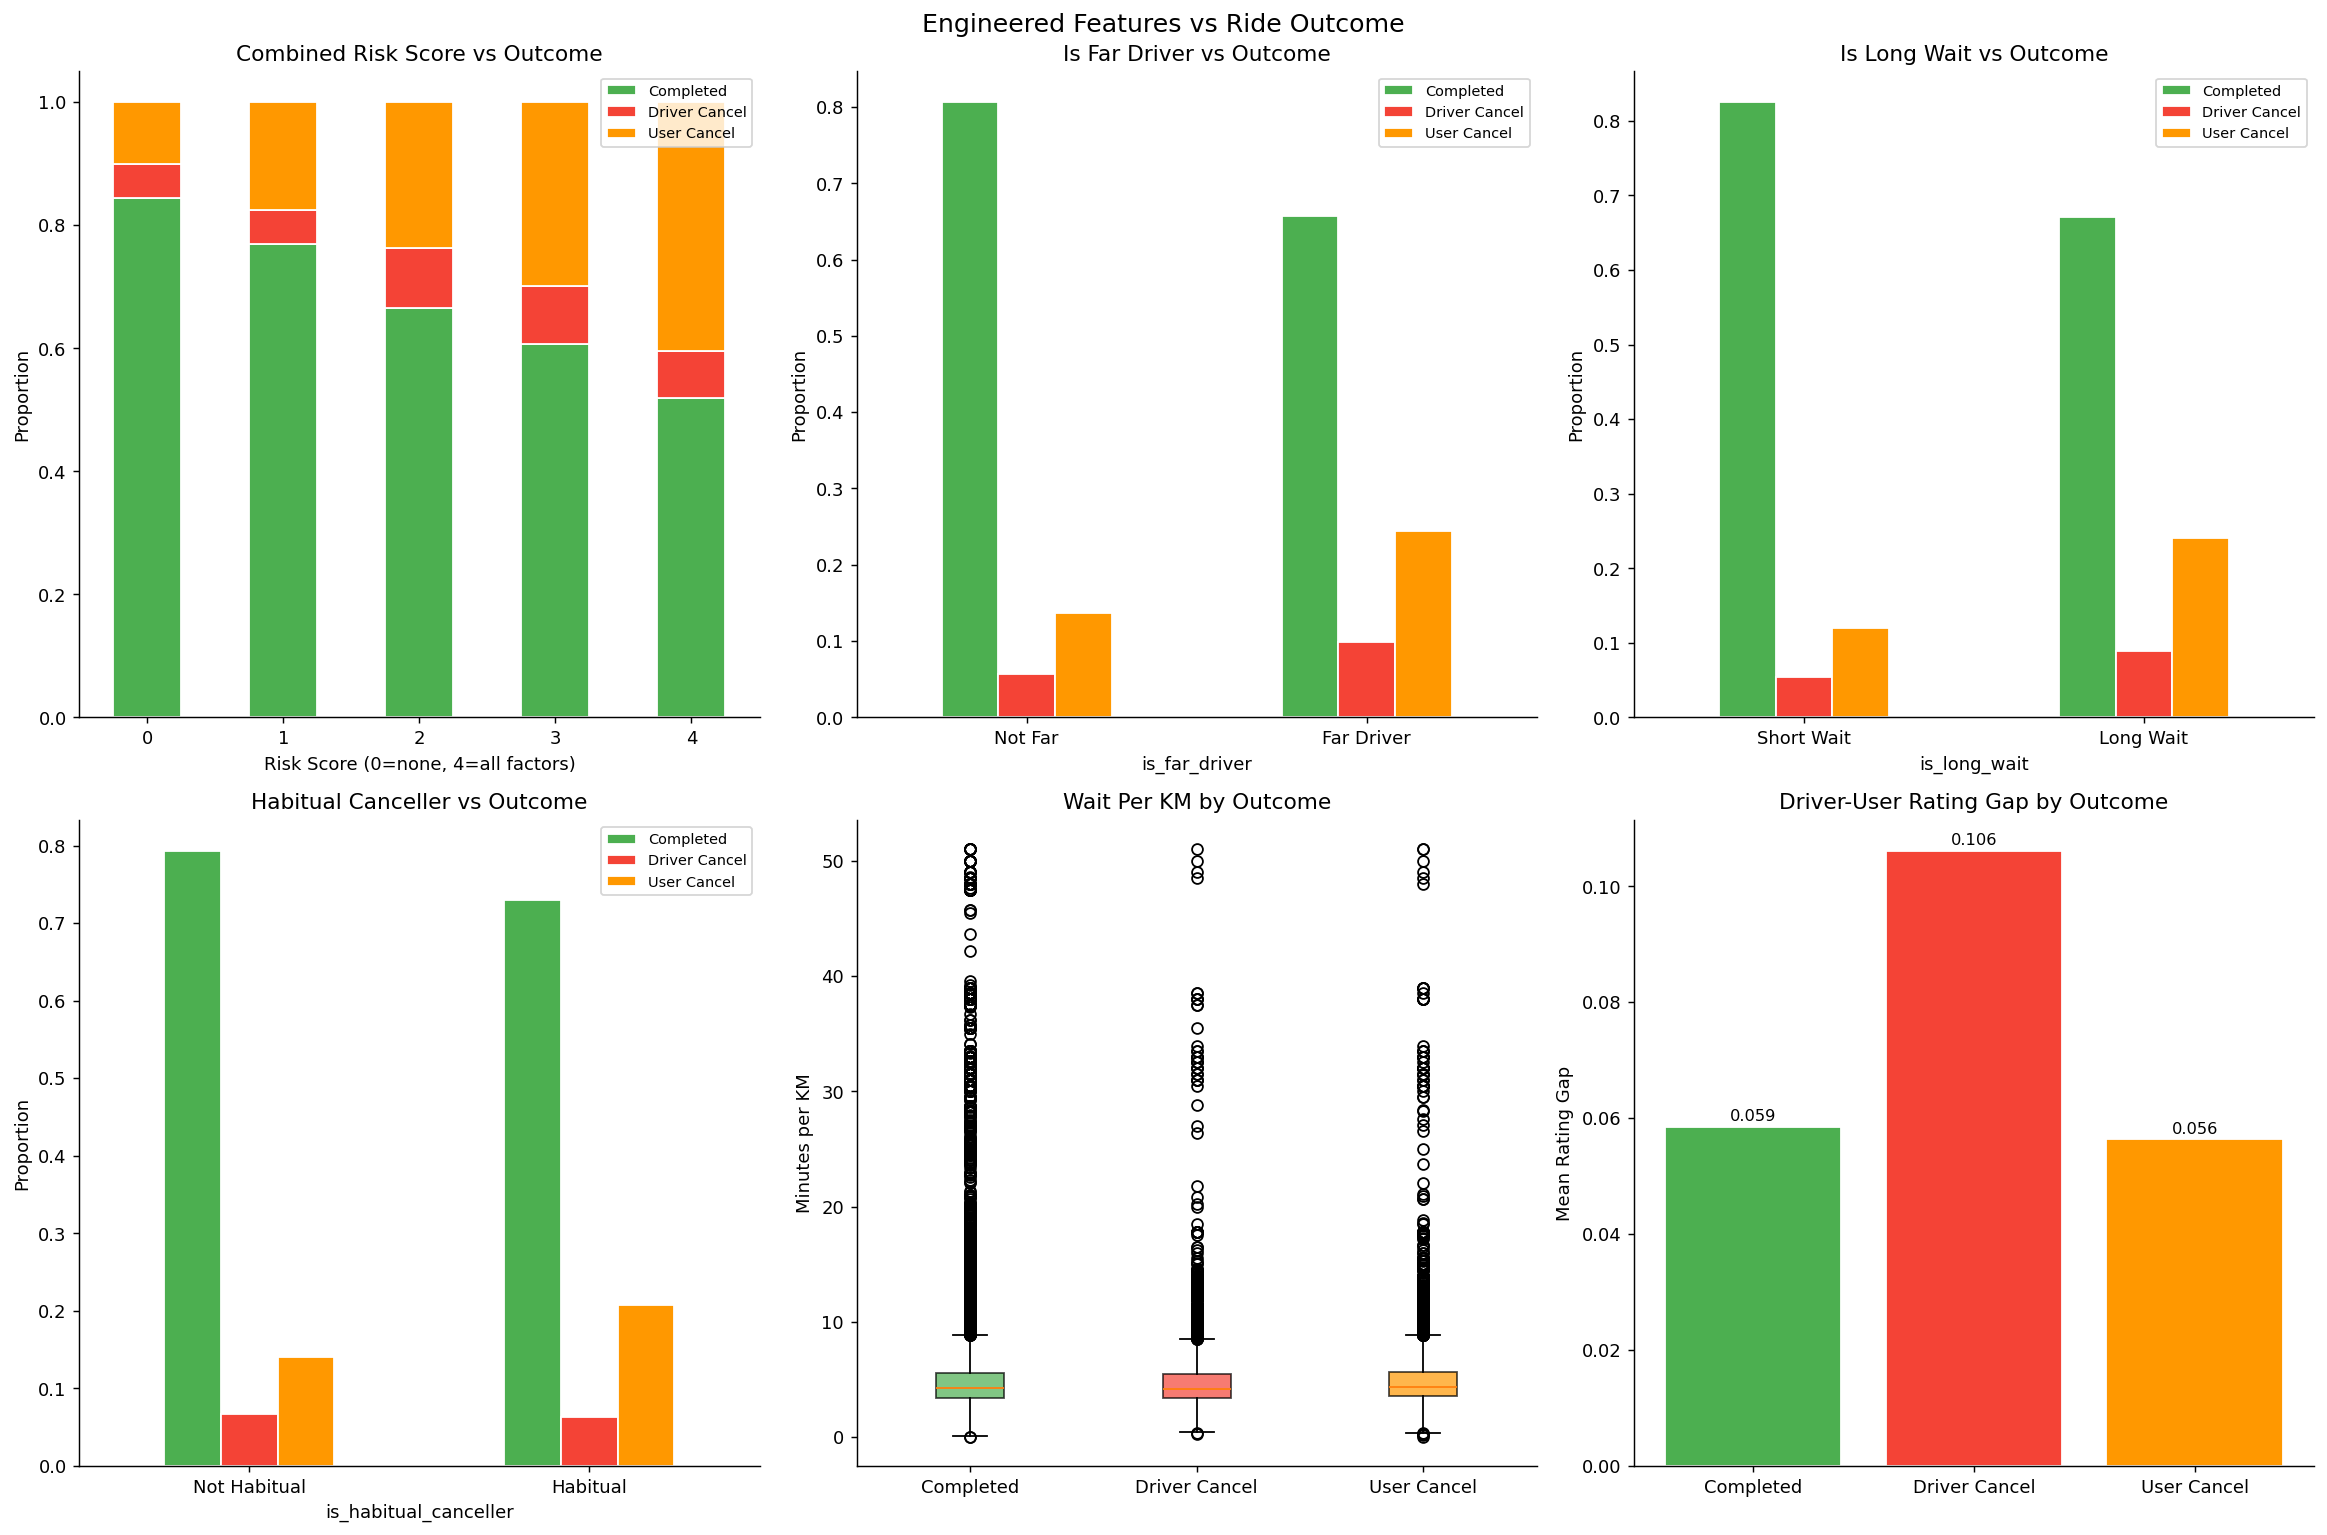

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Engineered Features vs Ride Outcome", fontsize=14)

# Combined risk score distribution by outcome
risk_outcome = rides_df.groupby(["combined_risk_score","ride_outcome"]).size().unstack(fill_value=0)
risk_outcome_pct = risk_outcome.div(risk_outcome.sum(axis=1), axis=0)

risk_outcome_pct.plot(
    kind="bar", ax=axes[0][0], stacked=True,
    color=[OUTCOME_COLORS[0],OUTCOME_COLORS[1],OUTCOME_COLORS[2]],
    edgecolor="white"
)
axes[0][0].set_title("Combined Risk Score vs Outcome")
axes[0][0].set_xlabel("Risk Score (0=none, 4=all factors)")
axes[0][0].set_ylabel("Proportion")
axes[0][0].tick_params(axis="x", rotation=0)
axes[0][0].legend([OUTCOME_LABELS[k] for k in [0,1,2]], fontsize=8)

# is_far_driver vs outcome
far_driver_rates = rides_df.groupby("is_far_driver")["ride_outcome"].value_counts(
    normalize=True
).unstack(fill_value=0)
far_driver_rates[[0,1,2]].plot(
    kind="bar", ax=axes[0][1],
    color=[OUTCOME_COLORS[k] for k in [0,1,2]],
    edgecolor="white"
)
axes[0][1].set_title("Is Far Driver vs Outcome")
axes[0][1].set_xticklabels(["Not Far","Far Driver"], rotation=0)
axes[0][1].set_ylabel("Proportion")
axes[0][1].legend([OUTCOME_LABELS[k] for k in [0,1,2]], fontsize=8)

# is_long_wait vs outcome
long_wait_rates = rides_df.groupby("is_long_wait")["ride_outcome"].value_counts(
    normalize=True
).unstack(fill_value=0)
long_wait_rates[[0,1,2]].plot(
    kind="bar", ax=axes[0][2],
    color=[OUTCOME_COLORS[k] for k in [0,1,2]],
    edgecolor="white"
)
axes[0][2].set_title("Is Long Wait vs Outcome")
axes[0][2].set_xticklabels(["Short Wait","Long Wait"], rotation=0)
axes[0][2].set_ylabel("Proportion")
axes[0][2].legend([OUTCOME_LABELS[k] for k in [0,1,2]], fontsize=8)

# is_habitual_canceller vs outcome
habit_rates = rides_df.groupby("is_habitual_canceller")["ride_outcome"].value_counts(
    normalize=True
).unstack(fill_value=0)
habit_rates[[0,1,2]].plot(
    kind="bar", ax=axes[1][0],
    color=[OUTCOME_COLORS[k] for k in [0,1,2]],
    edgecolor="white"
)
axes[1][0].set_title("Habitual Canceller vs Outcome")
axes[1][0].set_xticklabels(["Not Habitual","Habitual"], rotation=0)
axes[1][0].set_ylabel("Proportion")
axes[1][0].legend([OUTCOME_LABELS[k] for k in [0,1,2]], fontsize=8)

# Wait per km by outcome — boxplot
data_wpk = [
    rides_df[rides_df["ride_outcome"]==k]["wait_per_km"].dropna()
    for k in [0,1,2]
]
bp = axes[1][1].boxplot(data_wpk, patch_artist=True,
                         labels=[OUTCOME_LABELS[k] for k in [0,1,2]])
for patch, k in zip(bp["boxes"], [0,1,2]):
    patch.set_facecolor(OUTCOME_COLORS[k])
    patch.set_alpha(0.7)
axes[1][1].set_title("Wait Per KM by Outcome")
axes[1][1].set_ylabel("Minutes per KM")

# Driver user rating gap by outcome
gap_means = rides_df.groupby("ride_outcome")["driver_user_rating_gap"].mean()
axes[1][2].bar(
    [OUTCOME_LABELS[k] for k in gap_means.index],
    gap_means.values,
    color=[OUTCOME_COLORS[k] for k in gap_means.index],
    edgecolor="white"
)
axes[1][2].set_title("Driver-User Rating Gap by Outcome")
axes[1][2].set_ylabel("Mean Rating Gap")
for i, (k,v) in enumerate(gap_means.items()):
    axes[1][2].text(i, v + 0.001, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("../data/processed/fe_02_engineered_features.png",
            dpi=150, bbox_inches="tight")
plt.show()

## Step 8 — Class Imbalance Handling

### The Problem
Our class distribution:
  Completed       : 77.7%
  User Cancel     : 15.8%
  Driver Cancel   :  6.5%

A model trained without any adjustment will be heavily biased
toward predicting "Completed" — because being wrong 22% of the
time (predicting completed for all cancellations) still gives
78% overall accuracy.

### Strategy 1: Class Weights
Tell the model to penalize mistakes on minority classes more
heavily. A mistake on a Driver Cancel (6.5%) should hurt more
than a mistake on Completed (77.7%).

sklearn computes balanced weights automatically:
  weight = total_samples / (n_classes × samples_in_class)

### Strategy 2: SMOTE (Synthetic Minority Oversampling)
Create synthetic new examples of the minority classes by
interpolating between existing minority examples. This
makes the training set more balanced without just duplicating rows.

We prepare both strategies here. In Notebook 05 we will
train models with both and compare results.

In [12]:
# Compute balanced class weights
y = rides_df["ride_outcome"]
classes = np.array([0, 1, 2])

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y
)

class_weight_dict = dict(zip(classes, weights))

print("Balanced Class Weights:")
for k, w in class_weight_dict.items():
    count = (y == k).sum()
    pct   = count / len(y) * 100
    print(f"  Class {k} ({OUTCOME_LABELS[k]:<20}): "
          f"count={count:>7,} ({pct:.1f}%)  weight={w:.4f}")

print(f"\nInterpretation:")
print(f"  A Driver Cancel mistake is penalized {weights[1]/weights[0]:.1f}x")
print(f"  more than a Completed mistake")
print(f"  A User Cancel mistake is penalized {weights[2]/weights[0]:.1f}x")
print(f"  more than a Completed mistake")

Balanced Class Weights:
  Class 0 (Completed           ): count= 46,597 (77.7%)  weight=0.4292
  Class 1 (Driver Cancel       ): count=  3,922 (6.5%)  weight=5.0994
  Class 2 (User Cancel         ): count=  9,481 (15.8%)  weight=2.1095

Interpretation:
  A Driver Cancel mistake is penalized 11.9x
  more than a Completed mistake
  A User Cancel mistake is penalized 4.9x
  more than a Completed mistake


In [13]:
if SMOTE_AVAILABLE:
    # Build feature matrix before SMOTE
    # We do SMOTE only on training data in notebook 05
    # Here we just verify it works on a sample

    feature_cols_for_smote = [
        "driver_distance_to_pickup_km", "estimated_wait_time_min",
        "surge_at_booking", "driver_rating_at_booking",
        "driver_acceptance_rate", "user_rating_at_booking",
        "user_cancellations_last_30d", "user_booking_attempts",
        "pickup_accuracy_score", "hour_sin", "hour_cos",
        "month_sin", "month_cos", "weather_encoded",
        "pickup_zone_encoded", "drop_zone_encoded",
        "is_far_driver", "is_long_wait", "is_high_surge",
        "is_habitual_canceller", "combined_risk_score",
        "driver_user_rating_gap", "wait_per_km",
        "is_weekend", "is_holiday",
    ] + [c for c in rides_df.columns if c.startswith("day_")] \
      + [c for c in rides_df.columns if c.startswith("vehicle_")]

    feature_cols_for_smote = [
        c for c in feature_cols_for_smote if c in rides_df.columns
    ]

    X_sample = rides_df[feature_cols_for_smote].fillna(0).head(5000)
    y_sample = rides_df["ride_outcome"].head(5000)

    smote = SMOTE(random_state=42, k_neighbors=5)
    X_resampled, y_resampled = smote.fit_resample(X_sample, y_sample)

    print("SMOTE test on 5,000 sample rows:")
    print(f"  Before: {dict(pd.Series(y_sample).value_counts().sort_index())}")
    after_counts = dict(pd.Series(y_resampled).value_counts().sort_index())
    print(f"  After : {after_counts}")
    print(f"\n✅ SMOTE works correctly on this dataset")
    print(f"   Will apply to training data only in Notebook 05")
else:
    print("Install imbalanced-learn first:")
    print("  pip install imbalanced-learn")

Install imbalanced-learn first:
  pip install imbalanced-learn


In [16]:
TARGET = "ride_outcome"

feature_cols = [
    # Cyclical time
    "hour_sin", "hour_cos", "month_sin", "month_cos",
    # Binary time
    "is_weekend", "is_holiday",
    # Weather
    "weather_encoded",
    # Driver signals
    "driver_distance_to_pickup_km", "driver_rating_at_booking",
    "driver_acceptance_rate",
    # User signals
    "user_rating_at_booking", "user_cancellations_last_30d",
    "user_booking_attempts",
    # Contextual
    "estimated_wait_time_min", "surge_at_booking",
    "pickup_accuracy_score",
    # Zone encoded
    "pickup_zone_encoded", "drop_zone_encoded",
    # Engineered
    "is_far_driver", "is_long_wait", "is_high_surge",
    "is_habitual_canceller", "combined_risk_score",
    "driver_user_rating_gap", "wait_per_km",
] + [c for c in rides_df.columns if c.startswith("day_")] \
  + [c for c in rides_df.columns if c.startswith("vehicle_")]

# Keep only existing columns
feature_cols = [c for c in feature_cols if c in rides_df.columns]

# Exclude original categorical columns (keep only encoded versions)
feature_cols = [c for c in feature_cols if c not in 
                ["day_of_week", "vehicle_type", "pickup_zone", 
                 "drop_zone", "weather_condition"]]

# Build modeling dataset
modeling_df = rides_df[feature_cols + [TARGET]].dropna().reset_index(drop=True)

print("FINAL FEATURE MATRIX")
print(f"  Rows     : {len(modeling_df):,}")
print(f"  Features : {len(feature_cols)}")
print(f"  Target   : {TARGET}")
print(f"\nClass distribution in modeling dataset:")
for k in [0,1,2]:
    count = (modeling_df[TARGET] == k).sum()
    pct   = count / len(modeling_df) * 100
    print(f"  {OUTCOME_LABELS[k]:<20}: {count:>7,}  ({pct:.1f}%)")

print(f"\nFeature list ({len(feature_cols)} total):")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {col}")

FINAL FEATURE MATRIX
  Rows     : 60,000
  Features : 35
  Target   : ride_outcome

Class distribution in modeling dataset:
  Completed           :  46,597  (77.7%)
  Driver Cancel       :   3,922  (6.5%)
  User Cancel         :   9,481  (15.8%)

Feature list (35 total):
   1. hour_sin
   2. hour_cos
   3. month_sin
   4. month_cos
   5. is_weekend
   6. is_holiday
   7. weather_encoded
   8. driver_distance_to_pickup_km
   9. driver_rating_at_booking
  10. driver_acceptance_rate
  11. user_rating_at_booking
  12. user_cancellations_last_30d
  13. user_booking_attempts
  14. estimated_wait_time_min
  15. surge_at_booking
  16. pickup_accuracy_score
  17. pickup_zone_encoded
  18. drop_zone_encoded
  19. is_far_driver
  20. is_long_wait
  21. is_high_surge
  22. is_habitual_canceller
  23. combined_risk_score
  24. driver_user_rating_gap
  25. wait_per_km
  26. day_Monday
  27. day_Saturday
  28. day_Sunday
  29. day_Thursday
  30. day_Tuesday
  31. day_Wednesday
  32. vehicle_Bike
  33

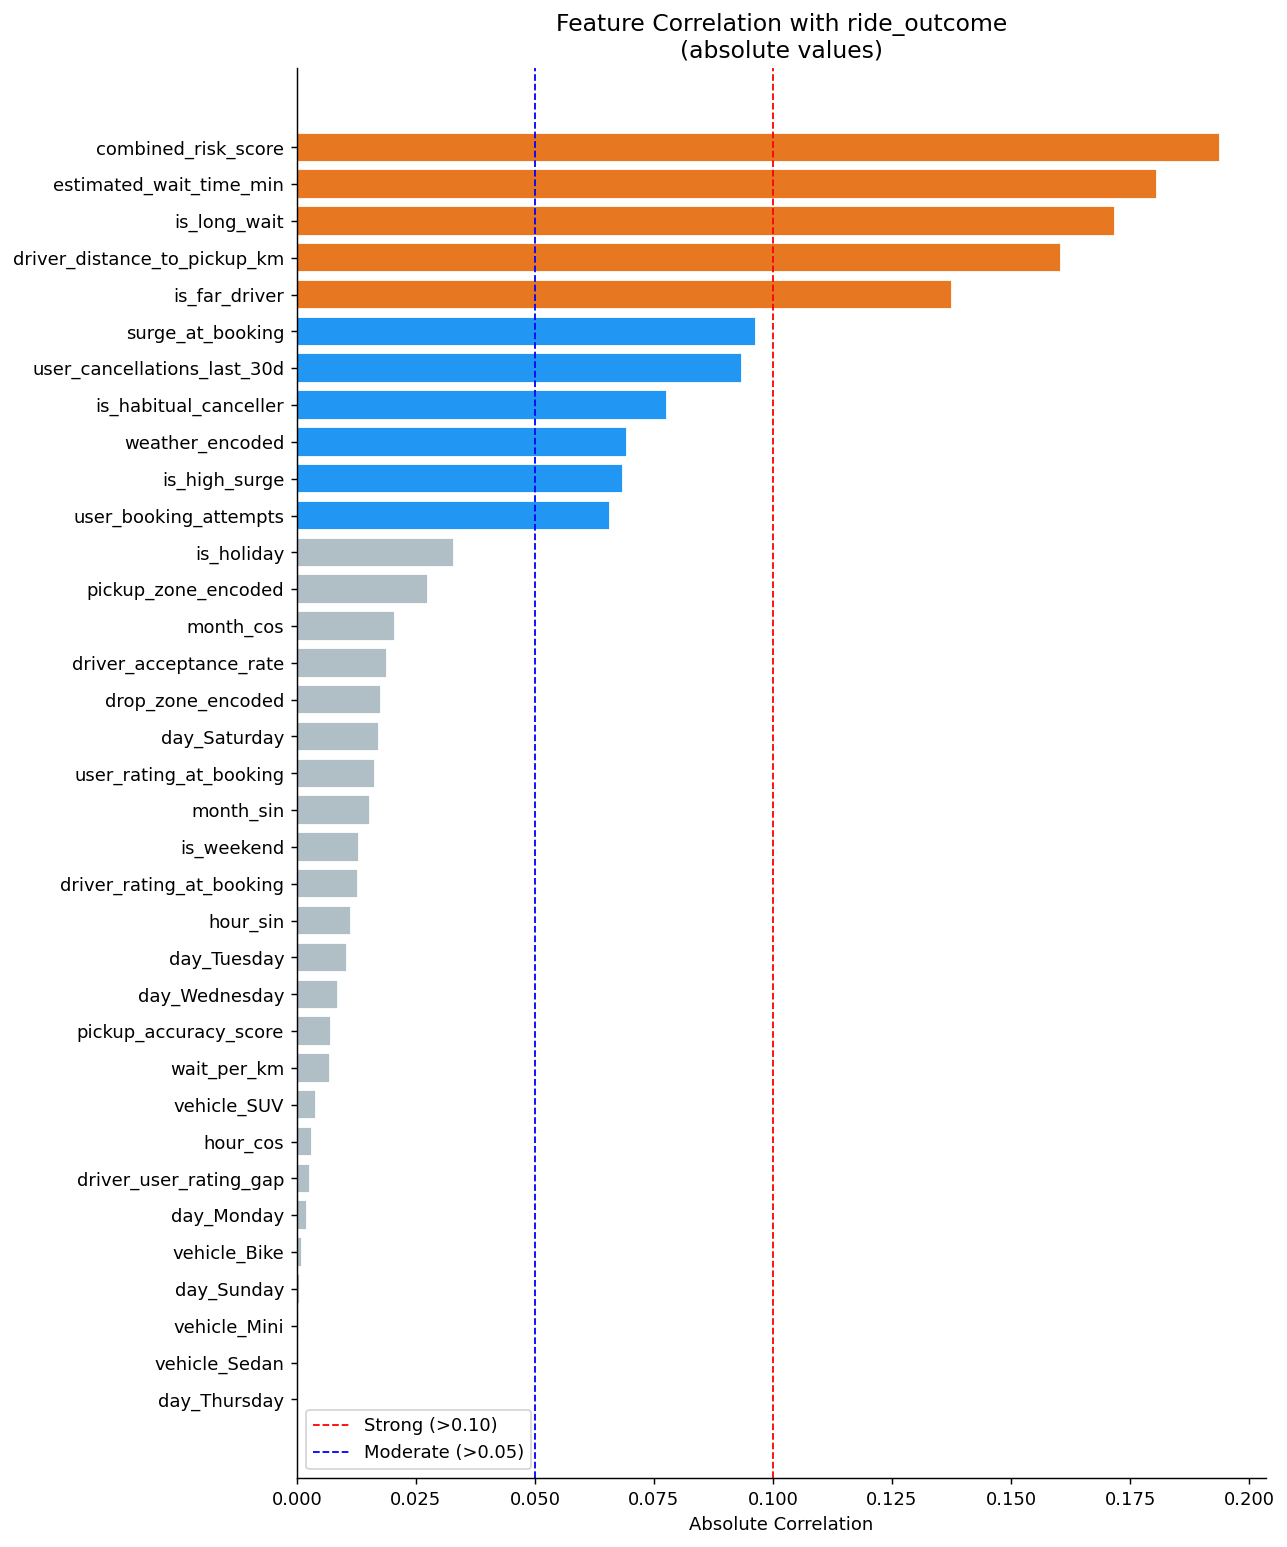

Top 10 features by correlation:
combined_risk_score            0.1938
estimated_wait_time_min        0.1807
is_long_wait                   0.1719
driver_distance_to_pickup_km   0.1605
is_far_driver                  0.1376
surge_at_booking               0.0965
user_cancellations_last_30d    0.0935
is_habitual_canceller          0.0777
weather_encoded                0.0694
is_high_surge                  0.0685
Name: ride_outcome, dtype: float64


In [17]:
corr_with_target = modeling_df[feature_cols + [TARGET]].corr()[TARGET].drop(TARGET)
corr_with_target = corr_with_target.abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
colors = [
    "#E87722" if v > 0.10 else
    "#2196F3" if v > 0.05 else
    "#B0BEC5"
    for v in corr_with_target.values
]

ax.barh(corr_with_target.index, corr_with_target.values,
        color=colors, edgecolor="white")
ax.set_title("Feature Correlation with ride_outcome\n(absolute values)",
             fontsize=13)
ax.set_xlabel("Absolute Correlation")
ax.axvline(0.10, color="red",  linestyle="--", linewidth=1, label="Strong (>0.10)")
ax.axvline(0.05, color="blue", linestyle="--", linewidth=1, label="Moderate (>0.05)")
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("../data/processed/fe_03_feature_correlation.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 features by correlation:")
print(corr_with_target.head(10).round(4))

In [18]:
import pickle

# Save modeling dataset
modeling_df.to_csv(PATH + "modeling_data.csv", index=False)

# Save full rides with all engineered features
rides_df.to_csv(PATH + "rides_engineered.csv", index=False)

# Save class weights for use in notebook 05
with open(PATH + "class_weights.pkl", "wb") as f:
    pickle.dump(class_weight_dict, f)

# Save feature column list
with open(PATH + "feature_cols.pkl", "wb") as f:
    pickle.dump(feature_cols, f)

print("✅ Saved to data/processed/")
print(f"  modeling_data.csv    : {len(modeling_df):,} rows × {len(modeling_df.columns)} columns")
print(f"  rides_engineered.csv : {len(rides_df):,} rows × {len(rides_df.columns)} columns")
print(f"  class_weights.pkl    : {class_weight_dict}")
print(f"  feature_cols.pkl     : {len(feature_cols)} features saved")
print(f"\nmodeling_data.csv is the direct input for Notebook 05")

✅ Saved to data/processed/
  modeling_data.csv    : 60,000 rows × 36 columns
  rides_engineered.csv : 60,000 rows × 51 columns
  class_weights.pkl    : {np.int64(0): np.float64(0.42921218104169795), np.int64(1): np.float64(5.099439061703213), np.int64(2): np.float64(2.1094821221390148)}
  feature_cols.pkl     : 35 features saved

modeling_data.csv is the direct input for Notebook 05


In [19]:
pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   ---------------------------------------- 2/2 [imbalanced-lea

## Feature Engineering Summary

| Feature | Type | Encoding | Reason |
|---|---|---|---|
| hour, month | Cyclical | sin + cos | Circular — 23 and 0 are adjacent |
| weather_condition | Ordinal | 0 to 5 | Natural severity order |
| pickup_zone, drop_zone | Target | Cancellation rate | 25 categories — encodes zone risk directly |
| day_of_week, vehicle_type | Nominal | One-hot | No natural order |
| is_far_driver | New binary | 0/1 | Driver > 4km = stronger cancel risk |
| is_long_wait | New binary | 0/1 | Wait > 12min = strongest predictor from EDA |
| is_high_surge | New binary | 0/1 | Surge > 2.0 = user cancel trigger |
| is_habitual_canceller | New binary | 0/1 | User cancelled 3+ times last 30d |
| combined_risk_score | New composite | 0 to 4 | Sum of all 4 binary risk flags |
| driver_user_rating_gap | New ratio | Continuous | Friction signal between driver and user |
| wait_per_km | New ratio | Continuous | Efficiency signal — time per distance |

## Class Imbalance Strategy
Two strategies prepared for Notebook 05:
1. class_weight="balanced" — penalize minority class errors more
2. SMOTE — create synthetic minority class examples

Both will be tested and compared.

## Data Leakage Prevention
Removed: distance_km, duration_min, fare_amount,
time_to_cancellation_min, cancelled_by, cancellation_reason
These are post-outcome columns — not available at booking time.

## Next Step → Notebook 05 — Model Training
3-class classification across 6 models, with class
imbalance handling comparison.